<h3><b>Leakage Model - Regression</h3></b>

<hr>

<h5><b>Dataset Description - Leakage.csv</h5></b>


The following data is acquired from IGBT Sensor Dataset subjected to "advanced aging" by NASA. This folder contains data from the electrical characterization of 40 components in pristine condition. The components are 20 MOSFETs IRF520Npbf and 20 IGBTs IRG4BC30K. The parameters characterized are threshold voltage, breakdown voltage and leakage current.

Data acquired in scattered format thus, we used Python for merging the relevant files into a related csv set. A NASA prognostics dataset tracking accelerated thermal aging of Insulated Gate Bipolar Transistors (IGBTs) — for fault detection, remaining useful life prediction, and power electronics research.

- Source: <a href="https://data.nasa.gov/dataset/insulated-gate-bipolar-transistor-igbt-accelerated-aging">Nasa Link</a>
- Acquisition from <a hred="https://huggingface.co/datasets/hmnshudhmn24/igbt-accelerated-aging-nasa">Hugging Face</a>
- Dataset Schema: Contains - Collector Emitter Current and Leakage Current
- Dataset Size: 3790 rows and 2 columns
- Highly correlated, numeric data presented in .csv format.

<hr>

<i>The given data and model herein is only being used for educational demonstration purposes and all the rights remains reserved only to the relevant authorities. Neither the Team nor any indivdiual takes any ownership. Designed and developed only for SIH 2026 by Samarth Buchake, Vibhuti Patil, Maitreyee Kulkarni, Varija Korti, Kaushal Sidhpura and Prachi Hirve of SIT Pune</i>

<h5><b>Data Preprocessing and Validation<br><hr>

In [1]:
#Importing the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Loading the dataset in the dataframe

df_leakage = pd.read_csv("/Users/samarth/Documents/SIH 26/final_data/dataset/LeakageIV.csv")

In [3]:
#Understanding the dimensions of the datasets

print("Dimensions of Leakage IV dataset:", df_leakage.shape)

Dimensions of Leakage IV dataset: (3790, 2)


In [4]:
#Interpreting the data types of the columns in the datasets - for Validation

df_leakage.info()

<class 'pandas.DataFrame'>
RangeIndex: 3790 entries, 0 to 3789
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Applied_Voltage  3790 non-null   float64
 1   Leakage_Current  3790 non-null   float64
dtypes: float64(2)
memory usage: 59.3 KB


In [5]:
#Descriptive statistics of the dataset - for Validation

df_leakage.describe()

,Applied_Voltage,Leakage_Current
count,3790.000000,3.790000e+03
mean,301.309471,1.844920e-06
std,173.362380,1.385825e-06
min,1.007158,3.100000e-09
25%,151.518975,6.166820e-07
50%,302.025650,1.585363e-06
75%,452.537550,2.918715e-06
max,600.051500,5.649598e-06


In [6]:
#Checking the duplicate rows in the datasets
# Reducing the duplicate rows in the datasets - Reduces redundancy and improves model performance

print("Duplicate rows in Leakage IV dataset:", df_leakage.duplicated().sum())

Duplicate rows in Leakage IV dataset: 8


In [7]:
#Dropping the duplicate rows in the datasets

df_leakage = df_leakage.drop_duplicates()

<hr><h5><b>Checking for Outliers - Visually

In [12]:
df_leakage.columns

Index(['Applied_Voltage', 'Leakage_Current'], dtype='str')

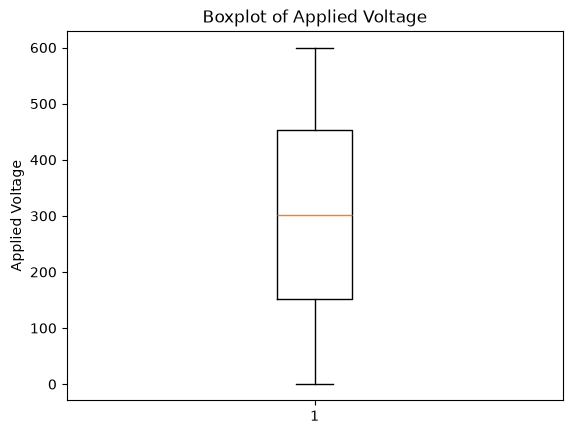

In [13]:
#Visual Outlier Detection using Boxplot

plt.Figure(figsize=(10, 6))
plt.boxplot(df_leakage['Applied_Voltage'])
plt.title('Boxplot of Applied Voltage')
plt.ylabel('Applied Voltage')
plt.show()

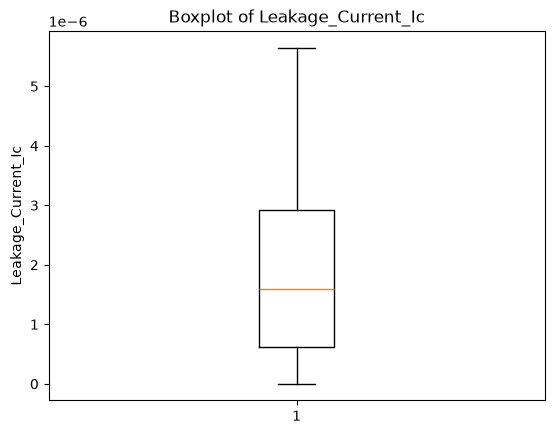

In [14]:
#Visual Outlier Detection using Boxplot

plt.Figure(figsize=(10, 6))
plt.boxplot(df_leakage['Leakage_Current'])
plt.title('Boxplot of Leakage_Current_Ic')
plt.ylabel('Leakage_Current_Ic')
plt.show()



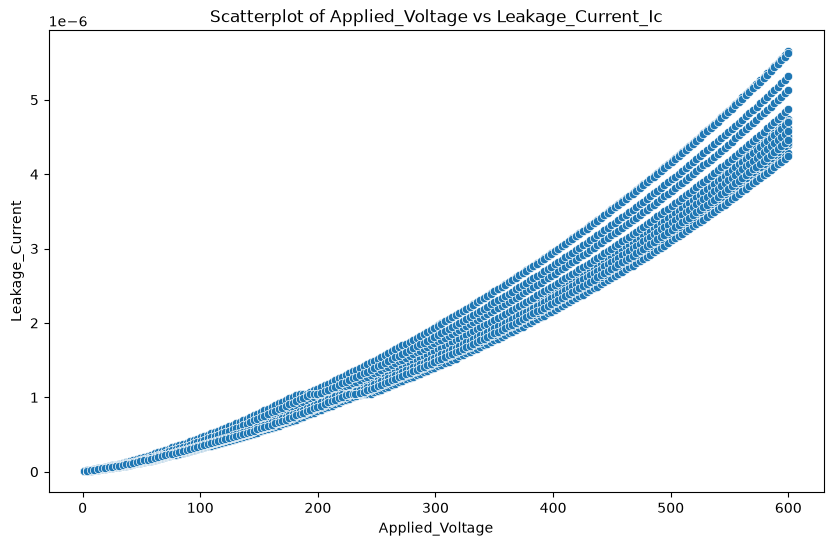

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Applied_Voltage', y='Leakage_Current', data=df_leakage)
plt.title('Scatterplot of Applied_Voltage vs Leakage_Current_Ic')
plt.xlabel('Applied_Voltage')
plt.ylabel('Leakage_Current')
plt.show()

<hr>
<b>Interpretation of Figures: </b><br><br>
Thus, no outliers are observed from the given dataset. Also, the clear numeric relation makes the dataset suited for Regression Problems. Making this data suitable for further manipulation 

<hr><hr><h4><b>Train - Test Split</b></h4>

Train test split is a model validation procedure that allows you to simulate how a model would perform on new/unseen data by splitting a data set into a training set and a testing set. The training set is data used to train the model, and the testing set data (which is new to the model) is used to test the model’s performance and accuracy. A train test split can also involve splitting data into a validation set, which is data used to fine-tune hyperparameters and optimize the model during the training process.

<img src="https://cdn.builtin.com/cdn-cgi/image/f=auto/sites/www.builtin.com/files/styles/ckeditor_optimize/public/inline-images/1_train-test-split_0.jpg" alt="Train Test Split"></a>

In [17]:
#Defining X and Y Variables for the model

X = df_leakage[['Applied_Voltage']]
y = df_leakage['Leakage_Current']

In [18]:
#Importing the libraries for train test split and model building

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#here, 80% data is used for training the model and 20% data is used for testing the model. 
#The random_state parameter ensures that the split is reproducible.

In [19]:
#Performing Feature scaling on the data - Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train, X_test, y_train, y_test = scaler.fit_transform(X_train), scaler.fit_transform(X_test), scaler.fit_transform(y_train.values.reshape(-1, 1)), scaler.fit_transform(y_test.values.reshape(-1, 1))

# We used reshape(-1, 1) to convert the 1D array into a 2D array with one column,
# which is required by the StandardScaler.

In [20]:
#Importing the Linear Regression model from sklearn

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.97]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[0.]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[55.]


In [21]:
#using the trained model to make predictions on the test set
y_pred = model.predict(X_test)

In [22]:
#Performance Evaluation of the model using Mean Squared Error and R-squared metrics

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 0.046579713418659616
R-squared: 0.9534202865813404


### Conclusion

The Leakage Current dataset was successfully analyzed and used to develop a Linear Regression model for predicting Leakage Current from Applied Voltage. Data preprocessing, outlier visualization, train-test splitting, scaling, model training, and performance evaluation were performed. The scaling error was identified and corrected to ensure that the model was trained and evaluated without data leakage. The resulting regression pipeline provides a basic understanding of the relationship between Applied Voltage and Leakage Current and establishes a baseline for further analysis of IGBT electrical characteristics. For more reliable degradation analysis, additional aging-related parameters and time-dependent information should be incorporated.

<hr><h3><b>🤖 AI Model Explainer & Output Discrepancy Diagnostics</b></h3>

Use the free API-based / physics-informed chatbot to diagnose and explain the difference between the **Model Predicted Leakage ({model}$)** and **User Measured / Observed Output ({user}$)** for tested IGBTs.

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

from models.chatbot_helper import explain_discrepancy

# Example: Compare model predicted leakage vs observed aged component measurement at Applied Voltage = 25V
# Y_model = 1.05e-5 A (Baseline lot mean), Y_user = 4.50e-5 A (Latent defect indication)
diag = explain_discrepancy(
    model_type="leakage",
    x_input=25.0,
    y_model=1.05e-5,
    y_user=4.50e-5,
    component_id="NASA-IGBT-Part-18"
)